In [1]:
from astropy.table import Table
target_ref = Table.read('/home/hmf/work/FA_test/inputs/targets.fits')

print(target_ref.keys())


['RELEASE', 'BRICKID', 'BRICKNAME', 'BRICK_OBJID', 'MORPHTYPE', 'RA', 'RA_IVAR', 'DEC', 'DEC_IVAR', 'DCHISQ', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'FRACFLUX_G', 'FRACFLUX_R', 'FRACFLUX_Z', 'FRACMASKED_G', 'FRACMASKED_R', 'FRACMASKED_Z', 'FRACIN_G', 'FRACIN_R', 'FRACIN_Z', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'PSFDEPTH_G', 'PSFDEPTH_R', 'PSFDEPTH_Z', 'GALDEPTH_G', 'GALDEPTH_R', 'GALDEPTH_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'FLUX_IVAR_W1', 'FLUX_IVAR_W2', 'FLUX_IVAR_W3', 'FLUX_IVAR_W4', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2', 'MW_TRANSMISSION_W3', 'MW_TRANSMISSION_W4', 'ALLMASK_G', 'ALLMASK_R', 'ALLMASK_Z', 'FIBERFLUX_G', 'FIBERFLUX_R', 'FIBERFLUX_Z', 'FIBERTOTFLUX_G', 'FIBERTOTFLUX_R', 'FIBERTOTFLUX_Z', 'REF_EPOCH', 'WISEMASK_W1', 'WISEMASK_W2', 'MASKBITS', 'FRACDEV', 'FRACDEV_IVAR', 'SHAPEDEV_R', 'SHAPEDEV_E1', 'SHAPEDEV_E2', 'SHAPEDEV_R_IVAR', 'SHAPEDEV_E1_IVAR', 'SHAPE

In [2]:
print(target_ref['RA'].min(), target_ref['RA'].max())   

112.68843410756122 157.26880082644192


In [ ]:
print(target_ref['SUBPRIORITY'].min(), target_ref['SUBPRIORITY'].max())

2.6349954582172153e-05 0.9999169324701138


In [14]:
print(np.unique(target_ref['DESI_TARGET']))

    DESI_TARGET    
-------------------
                257
                514
               1028
               1044
               1542
               1558
              65537
             131074
             262148
             262164
                ...
2305843009213694996
2305843009213759489
2305843009213956100
2305843009213956116
2305843017803628544
2305843017803890708
2305843026393563136
2305843052163366912
3458764513820803076
3458764513820803092
Length = 32 rows


In [ ]:

def generate_targets(box=[0., 6., 0., 6.], sci_density=3000., std_density=25., sky_density=100., outfile=None):
    '''
    Generate targets table
    DESI 10 standards / 40 skies per petal, -> 12.5 standards / 50 skies per deg2
    double the density to give more targets to allocate
    Args:
        box (4,) [deg]: [ra1, ra2, dec1, dec2] the coordinates of the box to generate targets
        sci/std/sky_density [deg-2]: number density of science/standard star/sky targets
        outfile (str): name of the output fits file of the generated targets table
    Outputs:
        A fits file storing the generated targets table
    '''
    target_class = [2**0, 2**33, 2**32] # target clas bitmask for science (LRG), standard (STD_FAINT), sky (SKY)
    ras, decs, classes = np.array([]).reshape(3, 0)
    for itype, density in enumerate([sci_density, std_density, sky_density]):
        ras_tmp, decs_tmp = random_points_by_density(box, density) # (npoints_per_type,)
        classes_tmp = [target_class[itype]] * len(ras_tmp)
        ras = np.hstack([ras, ras_tmp]).astype('float64')
        decs = np.hstack([decs, decs_tmp]).astype('float64')
        classes = np.hstack([classes, classes_tmp]).astype('int64')

In [2]:


base_dir = "/data/users/czhao/MUST/mocks/v0/npz/"

file = f"{base_dir}/MUST_BGS_z0.05z0.75.npz"

import numpy as np
data = np.load(file)

In [ ]:
print(BGS['Z'].min(), BGS['Z'].max())
print(BGS['ZERR'].min(), BGS['ZERR'].max())

In [3]:
import pandas as pd
from astropy.table import Table
import numpy as np
import glob

def convert_dat(filename, output_prefix, N=None):
    print(f"Reading {filename} ...")

    # 1. 用 pandas 读取（最快的 ASCII 方案）
    df = pd.read_csv(
        filename,
        delim_whitespace=True,
        comment='#',
        header=None,
        nrows=N
    )

    # 2. 设置列名（根据你的文件结构）
    df.columns = ['RA', 'DEC', 'Z', 'ZERR']

    print(f"Loaded {len(df)} rows")

    # 3. 转成 Astropy Table
    tab = Table.from_pandas(df)

    # # ===== 保存 FITS（推荐）=====
    # fits_file = f"{output_prefix}.fits"
    # tab.write(fits_file, overwrite=True)
    # print(f"Saved FITS: {fits_file}")

    # ===== 保存 NPY（可选，最快）=====
    npy_file = f"{output_prefix}.npy"
    np.save(npy_file, df.values)
    print(f"Saved NPY: {npy_file}")

    return tab


if __name__ == "__main__":
    for file in glob.glob('/data/users/czhao/MUST/mocks/v0/*.dat'):
        name_out = file.split('/')[-1].split('.dat')[0]
        convert_dat(
            filename=file,
            output_prefix=f'/home/hmf/work/FA_test/MUST_mock/{name_out}',
            N=None)   # 测试可以设 10000)

# BGS = load_dat_fast('/data/users/czhao/MUST/mocks/v0/MUST_BGS_z0.05z0.75.dat')


Reading /data/users/czhao/MUST/mocks/v0/MUST_BGS_z0.05z0.75.dat ...


/tmp/ipykernel_1537311/2401321996.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Loaded 30621712 rows
Saved NPY: /home/hmf/work/FA_test/MUST_mock/MUST_BGS_z0.05z0.75.npy
Reading /data/users/czhao/MUST/mocks/v0/MUST_ELG_z0.8z1.5.dat ...


/tmp/ipykernel_1537311/2401321996.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Loaded 51662300 rows
Saved NPY: /home/hmf/work/FA_test/MUST_mock/MUST_ELG_z0.8z1.5.npy
Reading /data/users/czhao/MUST/mocks/v0/MUST_LBG_z2z5.5.dat ...


/tmp/ipykernel_1537311/2401321996.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Loaded 24373241 rows
Saved NPY: /home/hmf/work/FA_test/MUST_mock/MUST_LBG_z2z5.5.npy
Reading /data/users/czhao/MUST/mocks/v0/MUST_LRG_z0.6z1.3.dat ...


/tmp/ipykernel_1537311/2401321996.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Loaded 12176686 rows
Saved NPY: /home/hmf/work/FA_test/MUST_mock/MUST_LRG_z0.6z1.3.npy


In [ ]:
print(data['data'][0])

[154.6507   78.32907 302.20703]


In [ ]:
# count = np.unique(data['data'][:,0])
print(len(count), len(data['data'][:,0]))

15074598 28962021


In [ ]:
print(data.keys())

KeysView(NpzFile '/data/users/czhao/MUST/mocks/v0/npz/MUST_BGS_z0.05z0.75.npz' with keys: data)


In [ ]:
print(np.min(data['data'][:,0]), np.max(data['data'][:,0]))
print(np.min(data['data'][:,1]), np.max(data['data'][:,1]))
print(np.min(data['data'][:,2]), np.max(data['data'][:,2]))

7.5640583e-06 360.0
-10.0 79.32079
168.97237 1840.7439


In [ ]:
import numpy as np
from astropy.table import Table, vstack
import glob

# =========================
# 1. Galaxy 配置（核心）
# =========================
GALAXY_CONFIG = {
    'BGS': {
        'PRIORITY_INIT': 1,
        'type_id': 0,
        'time': 0.04,
        'NUMOBS_INIT': int(np.ceil(0.04 * 3.0)),
        'OBSCONDITIONS': 2,
        'DESI_TARGET': np.int64(2**32)
    },
    # 'LRG': {
    #     'PRIORITY_INIT': 3,
    #     'type_id': 1,
    #     'time': 1.15,
    #     'NUMOBS_INIT': int(np.ceil(1.15 * 3.0)),
    #     'OBSCONDITIONS': 2,
    #     'DESI_TARGET': np.int64(2**0)
    # },
    # 'ELG': {
    #     'PRIORITY_INIT': 5,
    #     'type_id': 2,
    #     'time': 0.32,
    #     'NUMOBS_INIT': int(np.ceil(0.32 * 3.0)),
    #     'OBSCONDITIONS': 2,
    #     'DESI_TARGET': np.int64(2**1)
    # },
    # 'LBG': {
    #     'PRIORITY_INIT': 9,
    #     'type_id': 3,
    #     'time': lambda tab: np.where(tab['Z'] > 3.5, 5.8, 2.5),
    #     'NUMOBS_INIT': lambda tab: np.int32(np.ceil(tab['TIME'] * 3.0)),
    #     'OBSCONDITIONS': 1,
    #     'DESI_TARGET': np.int64(2**2)
    # }  
    # 以后可以直接扩展
}

# =========================
# 2. 读取 npz（支持 subset）
# =========================

def load_dat_as_table(filename, N=None):
    # 读取（自动跳过 # 注释行）
    tab = Table.read(filename, format='ascii')

    # 重命名列（非常重要！）
    tab.rename_columns(tab.colnames, ['RA', 'DEC', 'Z', 'ZERR'])

    # subset（用于测试）
    if N is not None:
        tab = tab[:N]

    return tab

def load_npz_as_table(filename, N=None, random=False):
    data = np.load(filename)
    keys = data.files

    n_total = len(data[keys[0]])

    if N is not None:
        if random:
            idx = np.random.choice(n_total, N, replace=False)
            subset = {k: data[k][idx] for k in keys}
        else:
            subset = {k: data[k][:N] for k in keys}
    else:
        subset = {k: data[k] for k in keys}

    return Table(subset)
def load_npy_as_table(filename, N=None, random=False):
    # mmap：不会一次性读入全部（大数据很重要）
    data = np.load(filename, mmap_mode='r')

    n_total = data.shape[0]

    # subset
    if N is not None:
        if random:
            idx = np.random.choice(n_total, N, replace=False)
            data = data[idx]
        else:
            data = data[:N]

    # ⚠️ 根据你的数据结构定义列名
    # 假设 npy = [RA, DEC, Z, ZERR]
    tab = Table()
    tab['RA'] = (((360. - data[:, 0] )+ 180) % 360) - 180 #
    tab['DEC'] = data[:, 1]
    tab['Z'] = data[:, 2]
    tab['Z_cosmo'] = data[:, 3]

    return tab

# =========================
# 3. 添加 galaxy 信息（通用版本）
# =========================
def add_galaxy_info(table, gal_type, config):
    n = len(table)

    table['GAL_TYPE'] = np.array([gal_type] * n, dtype='U8')

    # ---- 第一轮：常数列 ----
    for key, value in config[gal_type].items():
        if not callable(value):
            colname = key.upper()

            if isinstance(value, int):
                dtype = np.int32
            elif isinstance(value, float):
                dtype = np.float32
            else:
                dtype = None

            table[colname] = np.full(n, value, dtype=dtype)

    # ---- 第二轮：函数列 ----
    for key, value in config[gal_type].items():
        if callable(value):
            colname = key.upper()
            result = value(table)

            if isinstance(result, np.ndarray):
                table[colname] = result
            else:
                table[colname] = np.array(result)

    return table

# =========================
# 4. 主流程
# =========================
def main():

    # ===== 参数 =====
    N = None
    RANDOM = False
    base_dir = "/home/hmf/work/FA_test/MUST_mock/"
    # ===== 读取（改为 npy）=====
    cats=[]
    gts = []
    for gt in GALAXY_CONFIG.keys():
        file = f"{base_dir}/MUST_{gt}_*.npy"
        file = glob.glob(file)[0]
        print(f"Found file: {file}")
        cat = load_npy_as_table(file, N=N, random=RANDOM)
        # gt = file.split('/')[-1].split('_')[1]
        print(gt)
        gts.append(gt)

        # ===== 添加信息 =====
        cat_o = add_galaxy_info(cat, gt, GALAXY_CONFIG)
        cats.append(cat_o)

    # ===== 合并 =====
    merged = vstack(cats, join_type='outer')
    npoints = len(merged)
    merged.add_column(np.arange(npoints).astype('int64') + 1, name='TARGETID')
    merged.add_column(np.array([0.]*npoints).astype('float64'), name='SUBPRIORITY')
    # # ===== 输出 =====
    output_file = f'{base_dir}/MUST_merged_{"_".join(gts)}.fits'
    merged.write(output_file, overwrite=True)

    

    print(f"Saved to {output_file}")
    print(merged.keys())
    return merged

def main2():

    # ===== 参数 =====
    N = None
    RANDOM = False
    base_dir = "/home/hmf/work/FA_test/MUST_mock/"
    # ===== 读取（改为 npy）=====

    points = 0
    for gt in GALAXY_CONFIG.keys():
        file = f"{base_dir}/MUST_{gt}_*.npy"
        file = glob.glob(file)[0]
        print(f"Found file: {file}")
        cat = load_npy_as_table(file, N=N, random=RANDOM)
        # gt = file.split('/')[-1].split('_')[1]
        print(gt)

        # ===== 添加信息 =====
        cat_o = add_galaxy_info(cat, gt, GALAXY_CONFIG)
        # ===== 合并 =====

        npoints = len(cat_o)
        cat_o.add_column(np.arange(points, points+npoints).astype('int64') + 1, name='TARGETID')
        cat_o.add_column(np.random.uniform(low=0,high=1,size=npoints).astype('float64'), name='SUBPRIORITY')
        points+= len(cat_o)
    

        # # ===== 输出 =====
        # output_file = f'{base_dir}/MUST_{gt}.fits'
        # cat_o.write(output_file, overwrite=True)

    

        # print(f"Saved to {output_file}")
    return cat_o

# =========================
# 5. 执行
# =========================
if __name__ == "__main__":
    # merged = main()
    cat_o = main2()

Found file: /home/hmf/work/FA_test/MUST_mock/MUST_BGS_z0.05z0.75.npy
BGS


In [29]:
print(np.unique(merged['OBSCONDITIONS']))

OBSCONDITIONS
-------------
            1


# test my tables

In [4]:
from astropy.table import Table

# Tiles = Table.read('/home/hmf/work/FA_test/MUST_mock/tiles_DECaLS_GRAY_0.fits')
# Target = Table.read('/home/hmf/work/FA_test/MUST_mock/MUST_BGS.fits')

Tiles = Table.read('/home/hmf/work/FA_test/MUST_mock/tiles_CSST_DARK_1.fits')
Target = Table.read('/home/hmf/work/FA_test/MUST_mock/MUST_LBG.fits')

# print(Tiles)
print(Tiles.colnames)

['RA', 'DEC', 'TILEID', 'IN_DESI', 'PROGRAM', 'OBSCONDITIONS']


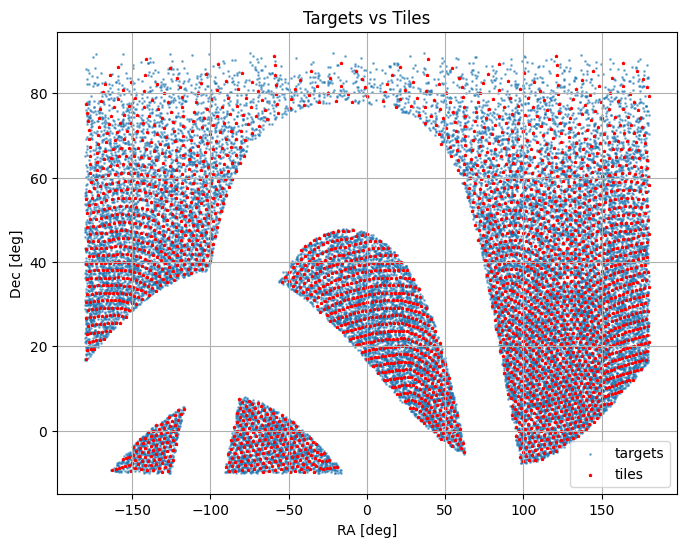

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- 统一 RA 到 [-180, 180] ---

sub = Target[::1000]
ra_tgt = sub['RA']
dec_tgt = sub['DEC']


ra_tile = Tiles['RA']
dec_tile = Tiles['DEC']

# --- 画图 ---
plt.figure(figsize=(8,6))

plt.scatter(ra_tgt, dec_tgt, s=1, alpha=0.5, label='targets')
plt.scatter(ra_tile, dec_tile, c='r', marker='*', s=3, label='tiles')

plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]')
plt.legend()
plt.title('Targets vs Tiles')

plt.grid()
plt.show()

In [ ]:
# 修改tile的OBSCONDITIONS为GRAY (2)
from astropy.table import Table
Tiles = Table.read('/home/hmf/work/FA_test/MUST_mock/tiles_DECaLS_GRAY_0_test.fits')


Tiles['OBSCONDITIONS'] = Tiles['OBSCONDITIONS']+2
Tiles.write('/home/hmf/work/FA_test/MUST_mock/tiles_DECaLS_GRAY_0_test_gray.fits', overwrite=True)
print("Modified tile saved as tiles_DECaLS_GRAY_0_test_gray.fits")



Modified tile saved as tiles_DECaLS_GRAY_0_test_gray.fits
Modified target saved as MUST_BGS.fits


In [4]:
print(Tiles['OBSCONDITIONS'].min(), Tiles['OBSCONDITIONS'].max())

2 2


In [3]:
for gt in [ 'LRG', 'ELG']:
    Target = Table.read(f'/home/hmf/work/FA_test/MUST_mock/MUST_{gt}.fits')
    Target['OBSCONDITIONS'] = Target['OBSCONDITIONS']+2
    Target.write(f'/home/hmf/work/FA_test/MUST_mock/MUST_{gt}.fits', overwrite=True)
    print(f"Modified target saved as MUST_{gt}.fits")

Modified target saved as MUST_LRG.fits
Modified target saved as MUST_ELG.fits
